<a href="https://colab.research.google.com/github/SamruddhiPowar5/Projects/blob/main/MicroExpressions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,Subset
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:
# Create models directory
!mkdir -p models

# Download the DLIB 68-point landmark model
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 -O models/shape_predictor_68_face_landmarks.dat.bz2

# Extract the file
!bzip2 -d models/shape_predictor_68_face_landmarks.dat.bz2

# Verify file exists
!ls models


--2026-01-09 14:14:42--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-01-09 14:14:42--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘models/shape_predictor_68_face_landmarks.dat.bz2’

models/shape_predic 100%[===================>]  61.07M  46.2MB/s    in 1.3s    

2026-01-09 14:14:44 (46.2 MB/s) - ‘models/shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file models/shape_predictor_68_face_landmarks.dat already exists.
shape_predictor_68_face_landmarks.dat
shape_predictor_68_face_landmarks.dat.bz2


In [4]:
import dlib

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(
    "models/shape_predictor_68_face_landmarks.dat"
)


In [5]:
def landmark_heatmap_dlib(gray_img, size=48):
    """
    gray_img: numpy array (48,48) normalized [0,1]
    """
    heatmap = np.zeros((size, size), dtype=np.float32)

    img_uint8 = (gray_img * 255).astype(np.uint8)
    faces = detector(img_uint8, 1)

    if len(faces) == 0:
        return heatmap

    shape = predictor(img_uint8, faces[0])

    for i in range(68):
        x = int(shape.part(i).x * size / img_uint8.shape[1])
        y = int(shape.part(i).y * size / img_uint8.shape[0])
        if 0 <= x < size and 0 <= y < size:
            heatmap[y, x] = 1.0

    heatmap = cv2.GaussianBlur(heatmap, (5,5), 0)
    return heatmap


In [6]:
class FER2013CSV(Dataset):
    def __init__(self, csv_path, use_landmarks=False):
        # Changed to use the csv_path parameter instead of a hardcoded path
        self.data = pd.read_csv(
    "/content/drive/MyDrive/ResearchModule/fer2013.csv",
    usecols=['emotion', 'pixels', 'Usage'],
    low_memory=False
)

        self.data = self.data[self.data['Usage'] == 'Training']
        self.pixels = self.data['pixels'].values
        self.labels = self.data['emotion'].values
        self.use_landmarks = use_landmarks

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = np.array(
            list(map(int, self.pixels[idx].split())),
            dtype=np.float32
        ).reshape(48, 48) / 255.0

        label = int(self.labels[idx])

        if self.use_landmarks:
            heatmap = landmark_heatmap_dlib(img)
            img = np.stack([img, heatmap], axis=0)  # (2,48,48)
        else:
            img = img[np.newaxis, :, :]             # (1,48,48)

        return torch.tensor(img, dtype=torch.float32), label

In [7]:
class ProposedModel1(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        def conv_block(in_c, out_c, k):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, k, padding=k//2, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ELU(inplace=True),
                nn.MaxPool2d(2,2),
                nn.Dropout(0.25)
            )

        self.block1 = conv_block(1, 64, 3)
        self.block2 = conv_block(64, 128, 5)
        self.block3 = conv_block(128, 512, 3)
        self.block4 = conv_block(512, 512, 3)

        self.fc1 = nn.Sequential(
            nn.Linear(512*3*3, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ELU(inplace=True),
            nn.Dropout(0.5)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(256, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.ELU(inplace=True),
            nn.Dropout(0.5)
        )

        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        return self.fc3(x)


In [8]:
class LandmarkGuidedCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        def conv_block(in_c, out_c, k):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, k, padding=k//2, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2,2)
            )

        self.block1 = conv_block(2, 64, 3)   #  2 channels
        self.block2 = conv_block(64, 128, 5)
        self.block3 = conv_block(128, 512, 3)
        self.block4 = conv_block(512, 512, 3)

        self.fc1 = nn.Sequential(
            nn.Linear(512*3*3, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(256, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25)
        )

        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        return self.fc3(x)


In [17]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    return avg_loss


In [18]:
def evaluate(model, loader, criterion):
    model.eval()
    preds, gts = [], []
    total_loss = 0.0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds.extend(outputs.argmax(1).cpu().numpy())
            gts.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    return avg_loss, gts, preds


In [19]:
def run_kfold_fast(model_class, dataset, max_epochs=3, max_samples=8000):

    kf = KFold(n_splits=2, shuffle=True, random_state=42)
    metrics = []

    for fold, (tr, val) in enumerate(kf.split(dataset)):
        print(f"\nFold {fold+1}/2")

        tr = tr[:max_samples]
        val = val[:max_samples // 2]

        train_loader = DataLoader(
            Subset(dataset, tr),
            batch_size=64,
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )

        val_loader = DataLoader(
            Subset(dataset, val),
            batch_size=64,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        model = model_class().to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()

        best_acc = 0
        patience = 1
        wait = 0

        # ---- TRAINING WITH LOSS TRACKING ----
        for epoch in range(max_epochs):

            train_loss = train_epoch(
                model, train_loader, optimizer, criterion
            )

            val_loss, gt, pr = evaluate(
                model, val_loader, criterion
            )

            acc = accuracy_score(gt, pr)

            print(
                f"Epoch {epoch+1} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val Acc: {acc:.4f}"
            )

            # ---- EARLY STOPPING ----
            if acc > best_acc:
                best_acc = acc
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered")
                    break

        p, r, f1, _ = precision_recall_fscore_support(
            gt, pr, average='macro', zero_division=0
        )

        metrics.append((best_acc, p, r, f1))

    return np.mean(metrics, axis=0)


In [20]:
import pandas as pd

In [21]:
# Path to FER-2013 CSV file (Google Drive)
CSV_PATH = "/content/drive/MyDrive/ResearchModule/fer2013.csv"

# Mount Google Drive to access the CSV file
from google.colab import drive
drive.mount('/content/drive')

# Baseline dataset (NO landmarks)
baseline_data = FER2013CSV(
    csv_path=CSV_PATH,
    use_landmarks=False
)

# Landmark-Guided dataset (WITH DLIB-68 heatmaps)
lm_data = FER2013CSV(
    csv_path=CSV_PATH,
    use_landmarks=True
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
print("\nRunning Baseline CNN")
acc_b, p_b, r_b, f1_b = run_kfold_fast(
    ProposedModel1,
    baseline_data,
    max_epochs=15
)

print("\nRunning Landmark-Guided CNN")
acc_l, p_l, r_l, f1_l = run_kfold_fast(
    LandmarkGuidedCNN,
    lm_data,
    max_epochs=8
)



Running Baseline CNN

Fold 1/2


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1 | Train Loss: 1.9641 | Val Loss: 1.7544 | Val Acc: 0.2890


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 2 | Train Loss: 1.8003 | Val Loss: 1.7012 | Val Acc: 0.3202


...

Epoch 1 | Train Loss: 1.6905 | Val Loss: 1.5186 | Val Acc: 0.4343


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 2 | Train Loss: 1.4352 | Val Loss: 1.4213 | Val Acc: 0.4600


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 3 | Train Loss: 1.2780 | Val Loss: 1.4426 | Val Acc: 0.4577
Early stopping triggered


In [23]:
print("\n FINAL 2-FOLD RESULTS ")
print(f"Baseline CNN  → Accuracy:{acc_b:.4f}  Precision:{p_b:.4f}  F1-Score:{f1_b:.4f}")
print(f"LM-CNN → Accuracy:{acc_l:.4f}  Precision:{p_l:.4f}  F1-Score:{f1_l:.4f}")



 FINAL 2-FOLD RESULTS 
Baseline CNN  → Accuracy:0.4808  Precision:0.4214  F1-Score:0.3696
LM-CNN → Accuracy:0.4680  Precision:0.4667  F1-Score:0.3846


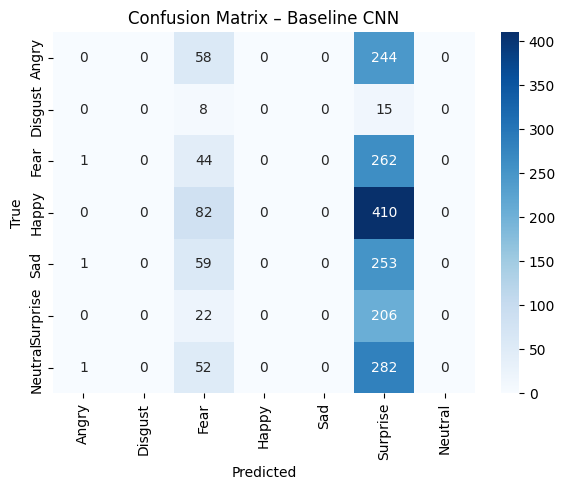

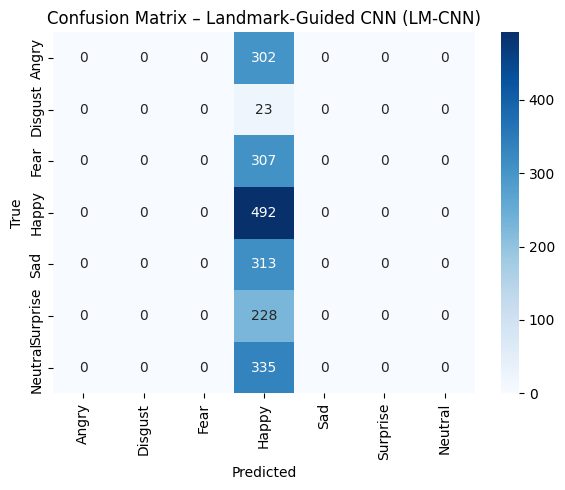

In [24]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix

# FER-2013 class labels
classes = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

# get predictions
def get_predictions(model, dataset, n_samples=2000):
    model.eval()
    y_true, y_pred = [], []

    loader = DataLoader(
        Subset(dataset, range(n_samples)),
        batch_size=64,
        shuffle=False
    )

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())

    return y_true, y_pred

# plot confusion matrix
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Create models
baseline_model = ProposedModel1().to(device)
lm_model = LandmarkGuidedCNN().to(device)

criterion = torch.nn.CrossEntropyLoss()

opt_base = torch.optim.Adam(baseline_model.parameters(), lr=1e-4)
opt_lm   = torch.optim.Adam(lm_model.parameters(), lr=1e-4)

train_loader_base = DataLoader(
    Subset(baseline_data, range(3000)),
    batch_size=64,
    shuffle=True
)
train_loader_lm = DataLoader(
    Subset(lm_data, range(1500)),
    batch_size=64,
    shuffle=True
)

# One epoch each
for x, y in train_loader_base:
    x, y = x.to(device), y.to(device)
    opt_base.zero_grad()
    loss = criterion(baseline_model(x), y)
    loss.backward()
    opt_base.step()
    break
for x, y in train_loader_lm:
    x, y = x.to(device), y.to(device)
    opt_lm.zero_grad()
    loss = criterion(lm_model(x), y)
    loss.backward()
    opt_lm.step()
    break

# Generate predictions
y_true_b, y_pred_b = get_predictions(baseline_model, baseline_data)
y_true_l, y_pred_l = get_predictions(lm_model, lm_data)

# Plot confusion matrices
plot_cm(y_true_b, y_pred_b, "Confusion Matrix – Baseline CNN")
plot_cm(y_true_l, y_pred_l, "Confusion Matrix – Landmark-Guided CNN (LM-CNN)")
